Linear and Non-linear Regression
Question: Predict rent from features and compare linear vs non-linear models.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
data_path = r"d:\smartnest.ai\dataset\House_Rent_Dataset_TN_synthetic_text_1500.csv"
df = pd.read_csv(data_path)
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,...,Listing_Description,Amenities_Text,Landmarks_Text,Reviews_Text,Complaints_Text,Lease_Rules_Text,Inquiry_Text,Inspection_Notes_Text,Scam_Flag,Scam_Rationale
0,2022-07-06,2,15000,1100,1 out of 2,super area,medavakkam,chennai,semi-furnished,bachelors,...,2 bhk semi-furnished home of 1100 sq ft (super...,"rainwater harvesting, play area, solar lightin...",near college (3.3 km); near hospital (0.6 km);...,clean and well maintained building. | safe are...,not_applicable,no smoking inside the house. tenant must follo...,looking for a 2 bhk near medavakkam within inr...,flooring shows normal wear. bathrooms are clea...,no,not_applicable
1,2022-05-21,2,6500,1000,ground out of 1,super area,"urapakkam, vandalur r.f, gst road",chennai,semi-furnished,bachelors/family,...,2 bhk semi-furnished home of 1000 sq ft (super...,"visitor parking, cctv, power backup, club hous...",near market (3.5 km); near school (0.8 km); ne...,clean and well maintained building. | good wat...,listing photos did not match actual house.,security deposit is two months rent. no loud m...,"want to move in next month, budget around inr ...",flooring shows normal wear. good natural light...,yes,owner refused physical visit. | asked for paym...
2,2022-05-20,3,90000,2400,1 out of 3,carpet area,"r.a puram, mandaiveli",chennai,semi-furnished,bachelors/family,...,3 bhk semi-furnished home of 2400 sq ft (carpe...,"waste management, power backup, lift, fire saf...",near pharmacy (0.6 km); near church (0.6 km),good water supply and quiet neighborhood. | ma...,not_applicable,security deposit is two months rent. maintenan...,"want to move in next month, budget around inr ...",electrical fittings are working properly. floo...,no,not_applicable
3,2022-07-10,3,200000,3000,1 out of 1,super area,madras boat club road,chennai,furnished,family,...,3 bhk furnished home of 3000 sq ft (super area...,"security, play area, gym, maintenance staff, w...",near mosque (3.4 km); near atm (1.8 km),parking is convenient and secure. | spacious r...,not_applicable,maintenance charges are extra. pets allowed on...,"want to move in next month, budget around inr ...",walls need minor repainting. good natural ligh...,no,not_applicable
4,2022-06-25,1,15000,650,ground out of 2,carpet area,kambar colony,chennai,semi-furnished,bachelors/family,...,1 bhk semi-furnished home of 650 sq ft (carpet...,"maintenance staff, security, rainwater harvest...",near atm (3.5 km); near hospital (3.8 km); nea...,easy access to public transport. | maintenance...,not_applicable,pets allowed only with prior approval. no loud...,"need a semi-furnished home in chennai, prefer ...",bathrooms are clean and functional. walls need...,no,not_applicable


In [3]:
total_missing = df.isna().sum().sum()
missing_by_col = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(total_missing))
missing_by_col[missing_by_col > 0].head(20)

Total missing values: 0


Series([], dtype: int64)

In [4]:
placeholder = "not_applicable"
df["Complaints_Text"] = df["Complaints_Text"].replace({"None": placeholder}).fillna(placeholder)
df["Scam_Rationale"] = df["Scam_Rationale"].replace({"None": placeholder}).fillna(placeholder)

df.to_csv(data_path, index=False)

total_missing = df.isna().sum().sum()
missing_by_col = df.isna().sum().sort_values(ascending=False)
print("Total missing values after fill:", int(total_missing))
missing_by_col[missing_by_col > 0].head(20)

Total missing values after fill: 0


Series([], dtype: int64)

In [5]:
df_clean = df.copy()
y = pd.to_numeric(df_clean["Rent"], errors="coerce")
X = df_clean.drop(columns=["Rent", "Description", "IsSynthetic"], errors="ignore")

for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].fillna("Unknown")
for col in X.select_dtypes(include="number").columns:
    X[col] = X[col].fillna(X[col].median())
y = y.fillna(y.median())

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

C:\Users\dell_\AppData\Local\Temp\ipykernel_33112\1814865791.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [6]:
models = {
    "Linear (LinearRegression)": LinearRegression(),
    "Non-linear (RandomForest)": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy_pct": r2 * 100,
    })

pd.DataFrame(results)

,Model,MAE,RMSE,R2,Accuracy_pct
0,Linear (LinearRegression),8850.142154,14604.573023,0.731981,73.198066
1,Non-linear (RandomForest),4586.698733,12403.453062,0.806681,80.668141


In [7]:
sample_row = X_test.iloc[[0]]
actual_rent = y_test.iloc[0]
print("Actual rent:", round(float(actual_rent), 2))
for name, fitted_model in models.items():
    pred = fitted_model.predict(sample_row)[0]
    print(f"{name} predicted: {pred:.2f}")

Actual rent: 26049.0
Linear (LinearRegression) predicted: 24273.79
Non-linear (RandomForest) predicted: 23910.41


Save and Load


In [8]:
import pickle

In [9]:
with open('linear_model_pickle.pkl', 'wb') as file:
    pickle.dump(models["Linear (LinearRegression)"], file)

In [10]:
with open('linear_model_pickle.pkl', 'rb') as file:
    mp = pickle.load(file)

In [11]:
sample_row = X_test.iloc[[0]]
predicted_rent = mp.predict(sample_row)[0]
actual_rent = y_test.iloc[0]
print("Loaded model prediction:", round(float(predicted_rent), 2))
print("Actual rent:", round(float(actual_rent), 2))

Loaded model prediction: 24273.79
Actual rent: 26049.0


In [12]:
mp.intercept_

np.float64(10927.213147003062)

In [13]:
mp.coef_

array([ -992.55255919,    33.93670587, -1690.80854277, ...,
        5442.49437497, -2372.45826882,  -102.84811724], shape=(6933,))

Save trained model using joblib

In [14]:
import joblib

joblib.dump(models["Linear (LinearRegression)"], 'model_joblib')

mj = joblib.load('model_joblib')


mj.intercept_


np.float64(10927.213147003062)

One hot encoding
Question: Predict rent from features using one-hot encoded categorical columns.

In [15]:
df_onehot = pd.get_dummies(df, drop_first=True)

y = pd.to_numeric(df_onehot["Rent"], errors="coerce")
X = df_onehot.drop(columns=["Rent"])

valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("One-hot shape:", df_onehot.shape)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

One-hot shape: (1500, 8434)
MAE: 8923.78
RMSE: 14580.03
R2: 0.7329


In [16]:
sample_row = X_test.iloc[[0]]
predicted_rent = model.predict(sample_row)[0]
actual_rent = y_test.iloc[0]
print("Predicted rent:", round(float(predicted_rent), 2))
print("Actual rent:", round(float(actual_rent), 2))

Predicted rent: 24570.42
Actual rent: 26049.0


Test and Train 

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

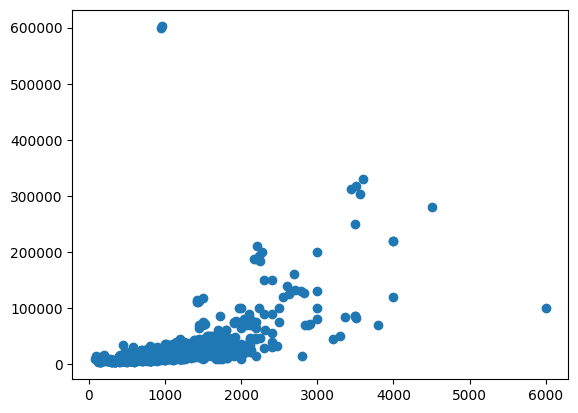

In [18]:
plt.scatter(pd.to_numeric(df['Size'], errors='coerce'), pd.to_numeric(df['Rent'], errors='coerce'))

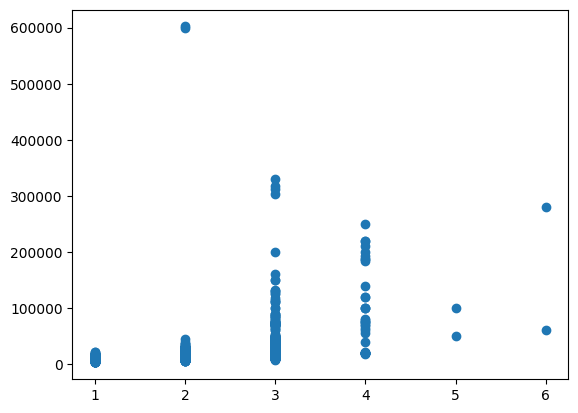

In [19]:
plt.scatter(pd.to_numeric(df['BHK'], errors='coerce'), pd.to_numeric(df['Rent'], errors='coerce'))

In [20]:
X = df[['Size','BHK']]
y = df['Rent']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)


In [21]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
clf.fit(X_train, y_train)
clf.predict(X_test)


array([ 1.78392367e+04,  1.78146190e+04,  1.34634720e+04,  4.18311875e+04,
        3.81533541e+04,  6.45538442e+04,  2.93985441e+03, -1.80665174e+02,
        2.15504523e+04,  1.71553543e+04,  2.15504523e+04,  1.02550504e+04,
        2.86705111e+04,  1.67844131e+04,  6.08619618e+04,  1.77251127e+03,
        1.39029818e+04,  5.59587854e+04,  7.86867264e+04,  1.71553543e+04,
        3.00962758e+04,  2.80551974e+04,  9.48993537e+04, -6.77331219e+03,
        3.03406483e+04,  2.03637758e+04,  4.52208970e+03,  2.81430993e+04,
        1.49578053e+04,  1.18372857e+04,  4.21443284e+03,  1.27602563e+04,
        2.15504523e+04,  2.50665307e+04,  4.40957007e+03,  2.02073052e+04,
        5.64668638e+04,  1.99682170e+04, -9.08498518e+02,  2.01688383e+03,
        1.24086485e+04,  1.27227942e+05,  1.95919915e+04,  1.05187563e+04,
        1.29360602e+04,  1.43864426e+04,  4.21443284e+03,  2.65801974e+04,
        3.97006027e+03,  5.42693148e+04,  3.56147659e+04, -2.11450830e+03,
        7.84423539e+04,  

In [22]:
clf.score(X_test, y_test)


0.42145909184707553

In [23]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=10)
X_test

,Size,BHK
633,281,1
56,674,2
1245,1283,2
1306,1516,3
1031,585,2
...,...,...
1124,709,2
177,1400,3
699,530,2
36,500,1
